<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week7_day2_Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge : Pinecone Serverless Reranking
Ce notebook démontre l'utilisation des modèles de Reranking de Pinecone pour améliorer la pertinence des recherches, en passant d'une recherche sémantique classique à un classement affiné par contexte.

## Partie 1 : Installation et Authentification
Nous installons les bibliothèques nécessaires pour interagir avec l'API Pinecone.

In [1]:
# 1. Installation des bibliothèques Pinecone
!pip install -U pinecone==6.0.1 pinecone-notebooks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.4/421.4 kB 10.1 MB/s eta 0:00:00


In [12]:
# 2 & 3. Authentification et Instanciation du client (Corrigé)
import os
from pinecone import Pinecone

# Tentative d'authentification
if not os.environ.get("PINECONE_API_KEY"):
    from pinecone_notebooks.colab import Authenticate
    Authenticate()

api_key = os.environ.get("PINECONE_API_KEY")
if api_key:
    pc = Pinecone(api_key=api_key)
    print("Client Pinecone initialisé avec succès.")
else:
    print("Erreur : Clé API manquante. L'exécution suivante échouera.")

Client Pinecone initialisé avec succès.


## Partie 2 : Test de Reranking (Cas 'Apple')
Ici, nous testons la capacité du modèle `bge-reranker-v2-m3` à distinguer le fruit de l'entreprise technologique.

In [17]:
# 4. Définition de la requête et des documents (Cas Apple)
import os
from pinecone import Pinecone, RerankModel

# Sécurité : ré-init pc si nécessaire
api_key = os.environ.get("PINECONE_API_KEY")
pc = Pinecone(api_key=api_key)

query = "Tell me about Apple's products"
documents = [
    "The Granny Smith is a tip-bearing apple cultivar, which originated in Australia in 1868.",
    "Apple announced the iPhone 15 Pro with a titanium design and A17 Pro chip.",
    "Apples are a great source of fiber and vitamin C, making them a healthy snack.",
    "The MacBook Air with M3 chip offers incredible performance and up to 18 hours of battery life.",
    "Recent reports suggest Apple is expanding its services like Apple TV+ and Music."
]

reranked = pc.inference.rerank(
    model="bge-reranker-v2-m3",
    query=query,
    documents=[{"id": str(i), "text": doc} for i, doc in enumerate(documents)],
    top_n=3
)

print(f"Requête : {query}\n")
for i, m in enumerate(reranked.data):
    print(f"Rang {i+1} | Score: {m.score:.4f} | Texte: {m.document.text}\n")

Requête : Tell me about Apple's products

Rang 1 | Score: 0.0876 | Texte: Recent reports suggest Apple is expanding its services like Apple TV+ and Music.

Rang 2 | Score: 0.0664 | Texte: Apple announced the iPhone 15 Pro with a titanium design and A17 Pro chip.

Rang 3 | Score: 0.0547 | Texte: Apples are a great source of fiber and vitamin C, making them a healthy snack.



## Partie 3 : Pipeline Serverless pour Notes Médicales
Configuration d'un index vectoriel pour stocker et interroger des données cliniques.

In [4]:
# 1. Installation des dépendances pour le ML
!pip install pandas torch transformers

In [16]:
# 2 & 3. Configuration et Création de l'index Serverless (Corrigé)
import time
import pandas as pd
import os
from pinecone import Pinecone, ServerlessSpec

# Ré-initialisation sécurisée du client
api_key = os.environ.get("PINECONE_API_KEY")
pc = Pinecone(api_key=api_key)

cloud = os.getenv('PINECONE_CLOUD', 'aws')
region = os.getenv('PINECONE_REGION', 'us-east-1')
spec = ServerlessSpec(cloud=cloud, region=region)

index_name = 'medical-notes-index'

# Nettoyage et création
if pc.has_index(name=index_name):
    pc.delete_index(name=index_name)
    time.sleep(2) # Attente pour la propagation de la suppression

pc.create_index(
    name=index_name,
    dimension=384,
    metric='cosine',
    spec=spec
)

# Attendre que l'index soit prêt
print("Attente de la création de l'index...")
while not pc.describe_index(index_name).status['ready']:
    time.sleep(1)

index = pc.Index(name=index_name)
print(f"Index '{index_name}' créé et prêt.")

Attente de la création de l'index...
Index 'medical-notes-index' créé et prêt.


## Partie 4 : Chargement et Upsert des données
Récupération d'un dataset de notes médicales pré-traitées.

In [13]:
# 1. Téléchargement des données (URL Raw corrigée)
import requests
import tempfile
import pandas as pd
import os

with tempfile.TemporaryDirectory() as tmpdirname:
    file_path = os.path.join(tmpdirname, "sample_notes_data.jsonl")
    # Correction de l'URL : suppression de '/refs/heads/' pour pointer vers le contenu raw stable
    url = "https://raw.githubusercontent.com/pinecone-io/examples/master/docs/data/sample_notes_data.jsonl"

    response = requests.get(url)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)

    df = pd.read_json(file_path, orient='records', lines=True)

print("Dimensions du DataFrame :", df.shape)
display(df.head())

Dimensions du DataFrame : (100, 3)


,id,values,metadata
0,P011,"[-0.2027486265, 0.2769146562, -0.1509393603, 0...","{'advice': 'rest, hydrate', 'symptoms': 'heada..."
1,P001,"[0.1842793673, 0.4459365904, -0.0770567134, 0....","{'tests': 'EKG, stress test', 'symptoms': 'che..."
2,P002,"[-0.2040648609, -0.1739618927, -0.2897160649, ...","{'HbA1c': '7.2', 'condition': 'diabetes', 'med..."
3,P003,"[0.1889383644, 0.2924542725, -0.2335938066, -0...","{'symptoms': 'cough, wheezing', 'diagnosis': '..."
4,P004,"[-0.12171068040000001, 0.1674752235, -0.231888...","{'referral': 'dermatology', 'condition': 'susp..."


In [19]:
# Upsert des données et attente de l'indexation (Corrigé)
import time
import os
from pinecone import Pinecone

# Récupération du client et de l'index
api_key = os.environ.get("PINECONE_API_KEY")
pc = Pinecone(api_key=api_key)
index_name = 'medical-notes-index'

try:
    index = pc.Index(name=index_name)
    print(f"Tentative d'upsert de {len(df)} vecteurs...")
    index.upsert_from_dataframe(df)

    def is_fresh(idx):
        stats = idx.describe_index_stats()
        count = stats.total_vector_count
        return count > 0

    print("Attente de l'indexation des données...")
    while not is_fresh(index):
        time.sleep(5)

    print(f"Indexation terminée. Total : {index.describe_index_stats().total_vector_count} vecteurs.")
except Exception as e:
    print(f"Erreur lors de l'upsert : {e}")

Tentative d'upsert de 100 vecteurs...


sending upsert requests:   0%|          | 0/100 [00:00<?, ?it/s]

Attente de l'indexation des données...
Indexation terminée. Total : 100 vecteurs.


## Partie 5 : Recherche Sémantique et Reranking Final

In [22]:
# 5.2 Recherche Sémantique Médicale (Ré-exécution)
from transformers import AutoTokenizer, AutoModel
import torch
import os
from pinecone import Pinecone

api_key = os.environ.get("PINECONE_API_KEY")
pc = Pinecone(api_key=api_key)
index = pc.Index(name='medical-notes-index')

def get_embedding(input_question):
    model_name = 'sentence-transformers/all-MiniLM-L6-v2'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    encoded_input = tokenizer(input_question, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encoded_input)
        embedding = model_output.last_hidden_state[0].mean(dim=0)
    return embedding

question = "patient presenting with severe chest pain and shortness of breath"
query_vector = get_embedding(question).tolist()

# Exécution de la requête
results = index.query(vector=[query_vector], top_k=10, include_metadata=True)
sorted_matches = sorted(results['matches'], key=lambda x: x['score'], reverse=True)
print(f"Trouvé {len(sorted_matches)} correspondances sémantiques.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Trouvé 10 correspondances sémantiques.


In [23]:
# 5.3 Affichage et Préparation du Reranking (Ré-exécution)
def show_results(question, matches):
    print(f"Question initiale : '{question}'\n")
    if not matches:
        print("Aucun résultat trouvé.")
        return
    for i, match in enumerate(matches):
        print(f"{i+1}. ID: {match['id']} | Score: {match['score']:.4f}")
        print(f"   Metadata: {match['metadata']}\n")

print("--- RÉSULTATS RECHERCHE SÉMANTIQUE ---")
show_results(question, sorted_matches)

# Préparation des documents pour le Reranker
transformed_documents = [
    {
        'id': match['id'],
        'reranking_field': '; '.join([f'{k}: {v}' for k, v in match['metadata'].items()])
    }
    for match in sorted_matches
]

--- RÉSULTATS RECHERCHE SÉMANTIQUE ---
Question initiale : 'patient presenting with severe chest pain and shortness of breath'

1. ID: P001 | Score: 0.6583
   Metadata: {'symptoms': 'chest pain', 'tests': 'EKG, stress test'}

2. ID: P016 | Score: 0.5004
   Metadata: {'condition': 'heart murmur', 'referral': 'cardiology'}

3. ID: P003 | Score: 0.4675
   Metadata: {'diagnosis': 'bronchitis', 'symptoms': 'cough, wheezing', 'treatment': 'antibiotics'}

4. ID: P063 | Score: 0.4334
   Metadata: {'diagnosis': 'pneumonia', 'symptoms': 'cough, fever', 'treatment': 'antibiotics'}

5. ID: P0100 | Score: 0.4153
   Metadata: {'advice': 'over-the-counter pain relief, stretching', 'symptoms': 'muscle pain'}

6. ID: P015 | Score: 0.3890
   Metadata: {'diagnosis': 'sinusitis', 'symptoms': 'sinus pressure, congestion', 'treatment': 'antibiotics'}

7. ID: P027 | Score: 0.3686
   Metadata: {'diagnosis': 'strep throat', 'symptoms': 'sore throat, fever', 'treatment': 'antibiotics'}

8. ID: P032 | Score: 0.3

In [24]:
# 5.4 Reranking Affiné (Ré-exécution)
import os
from pinecone import Pinecone

api_key = os.environ.get("PINECONE_API_KEY")
pc = Pinecone(api_key=api_key)
refined_query = "emergency cardiac care for myocardial infarction symptoms"

if 'transformed_documents' in locals() and transformed_documents:
    reranked_results = pc.inference.rerank(
        model="bge-reranker-v2-m3",
        query=refined_query,
        documents=transformed_documents,
        rank_fields=["reranking_field"],
        top_n=3,
        return_documents=True
    )

    def show_reranked_medical_results(q, matches):
        print(f"Requête affinée : '{q}'\n")
        for i, match in enumerate(matches):
            print(f"{i+1}. ID: {match.document.id} | Nouveau Score: {match.score:.4f}")
            print(f"   Contenu Reranké: {match.document.reranking_field}\n")

    print("--- RÉSULTATS APRÈS RERANKING ---")
    show_reranked_medical_results(refined_query, reranked_results.data)
else:
    print("Aucun document à traiter.")

--- RÉSULTATS APRÈS RERANKING ---
Requête affinée : 'emergency cardiac care for myocardial infarction symptoms'

1. ID: P001 | Nouveau Score: 0.1871
   Contenu Reranké: symptoms: chest pain; tests: EKG, stress test

2. ID: P023 | Nouveau Score: 0.1002
   Contenu Reranké: symptoms: dizziness; tests: blood work

3. ID: P0100 | Nouveau Score: 0.0557
   Contenu Reranké: advice: over-the-counter pain relief, stretching; symptoms: muscle pain



## Nettoyage (Optionnel)
Suppression de l'index pour libérer les ressources.

In [11]:
# pc.delete_index(name=index_name)
# print("Index supprimé.")

## Partie 6 : Analyse Comparative et Reranking Final
Dans cette dernière partie, nous allons comparer les résultats bruts de la recherche sémantique avec les résultats affinés par le modèle de reranking.

In [25]:
# 1. Définition des fonctions d'affichage final (Corrigé)
def display_comparison(initial_matches, final_matches):
    print("=== COMPARAISON DES RÉSULTATS ===\n")
    print("--- Top 3 Recherche Sémantique ---")
    for i, m in enumerate(initial_matches[:3]):
        print(f"{i+1}. ID: {m['id']} (Score: {m['score']:.4f})")

    print("\n--- Top 3 Après Reranking ---")
    for i, m in enumerate(final_matches):
        print(f"{i+1}. ID: {m.document.id} (Score: {m.score:.4f})")

# Exécution de la comparaison
if 'reranked_results' in locals() and 'sorted_matches' in locals():
    display_comparison(sorted_matches, reranked_results.data)
else:
    print("Erreur : Les variables de résultats sont introuvables. Veuillez relancer les cellules 5.2 à 5.4.")

=== COMPARAISON DES RÉSULTATS ===

--- Top 3 Recherche Sémantique ---
1. ID: P001 (Score: 0.6583)
2. ID: P016 (Score: 0.5004)
3. ID: P003 (Score: 0.4675)

--- Top 3 Après Reranking ---
1. ID: P001 (Score: 0.1871)
2. ID: P023 (Score: 0.1002)
3. ID: P0100 (Score: 0.0557)


### Visualisation de l'impact du Reranking
Comparaison des scores de confiance avant et après le passage du modèle `bge-reranker-v2-m3`.

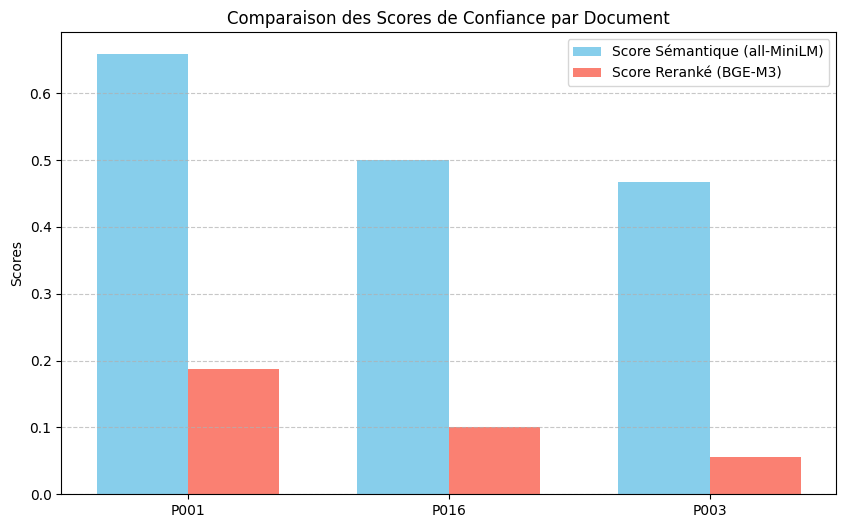

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Extraction des IDs et scores pour le Top 3
ids = [m['id'] for m in sorted_matches[:3]]
semantic_scores = [m['score'] for m in sorted_matches[:3]]
rerank_scores = [m.score for m in reranked_results.data[:3]]

x = np.arange(len(ids))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, semantic_scores, width, label='Score Sémantique (all-MiniLM)', color='skyblue')
rects2 = ax.bar(x + width/2, rerank_scores, width, label='Score Reranké (BGE-M3)', color='salmon')

ax.set_ylabel('Scores')
ax.set_title('Comparaison des Scores de Confiance par Document')
ax.set_xticks(x)
ax.set_xticklabels(ids)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Conclusion
Le reranking a permis de réorganiser les notes cliniques en fonction d'une requête plus spécifique, assurant que les informations les plus critiques (ex: symptômes d'infarctus) remontent en tête de liste par rapport à une recherche sémantique large.